In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from scipy import ndimage, optimize
from scipy.fft import fft2, ifft2
import cv2
import scipy.constants as c
import pandas as pd
from IPython.display import display

import beam_caustic


# Time of Flight Analysis

In [ ]:
def run_d4sigma(
    image: np.ndarray,
    *,
    pixel_size_x_mm: float = 8.4e-3,
    pixel_size_y_mm: float = 9.8e-6,
    self_conf_width: float = 3,
    bkg_ellipse_axes_scaling: float = 1.0,
    d4s_rel_tol: float | None = None,
    d4s_abs_tol: float = 1.0,
    debug_d4sigma: bool = False,
    make_fit_plots: bool = False,
    plot_label: str = "",
):
    """
    Analyze a single CCD sub-image (e.g., before-shutter or after-shutter region).

    Returns
    -------
    fit_dict : dict
        Parameters from the 2D Gaussian fit (from beam_caustic.fit_gaussian_2d).
    gaussian_model : callable
        Callable model gaussian_2d(*popt) that can be evaluated on coordinates.
    d4sigma_summary : dict
        Key results from the D4σ method.
    """

    # ----------------------------
    # 1) Estimate background region using an ellipse fit
    # ----------------------------
    xc_ell, yc_ell, minor_saxis_ell, major_saxis_ell, orientation_ell = beam_caustic.find_ellipse(image)

    ellipse_mask = beam_caustic.get_ellipse_mask(
        xc_ell, yc_ell,
        bkg_ellipse_axes_scaling * minor_saxis_ell,
        bkg_ellipse_axes_scaling * major_saxis_ell,
        orientation_ell,
        image.shape
    )

    # Background estimate from pixels *outside* the ellipse
    if np.any(~ellipse_mask):
        bkg_avg = float(image[~ellipse_mask].mean())
    else:
        # Fallback: if ellipse covers everything, assume zero background
        bkg_avg = 0.0

    image_bkg_corr = image.astype(float) - bkg_avg

    # ----------------------------
    # 2) Fit a 2D Gaussian (for center + waist estimates)
    # ----------------------------
    fit_result, fit_dict, gaussian_2d = beam_caustic.fit_gaussian_2d(
        image_bkg_corr,
        pstart=[
            image_bkg_corr.max(),
            xc_ell, yc_ell,
            minor_saxis_ell, major_saxis_ell,
            orientation_ell,
            0.0
        ],
    )

    # Convert (w0x, w0y) [pixels] -> 1/e^2 diameters in mm (matching your original)
    w_major_mm = 2 * fit_dict["w0x_Value"] * pixel_size_x_mm
    w_minor_mm = 2 * fit_dict["w0y_Value"] * pixel_size_y_mm

    # ----------------------------
    # 3) Run D4σ method (for ISO-style beam widths)
    # ----------------------------
    xc_d4s, yc_d4s, dx_d4s, dy_d4s, orientation_d4s, iterations_d4s, converged_d4s = (
        beam_caustic.run_d4sigma_method(
            image_bkg_corr,
            self_conf_width=self_conf_width,
            debug=debug_d4sigma,
            ignore_crop_error=True,
            rel_tol=d4s_rel_tol,
            abs_tol=d4s_abs_tol,
        )
    )

    d4sigma_summary = {
        "x0_px": float(xc_d4s),
        "y0_px": float(yc_d4s),
        "D4sigma_x_px": float(dx_d4s),
        "D4sigma_y_px": float(dy_d4s),
        "phi_deg": float(orientation_d4s),
        "iterations": int(iterations_d4s),
        "converged": bool(converged_d4s),
        "bkg_avg_cts": float(bkg_avg),
    }

    # ----------------------------
    # 4) Optional: diagnostic plots for this sub-image
    # ----------------------------
    if make_fit_plots:
        fig, axs = plt.subplots(1, 3, figsize=(14, 3.5), constrained_layout=True)
        fig.suptitle(f"2D Gaussian fit diagnostics {plot_label}".strip())

        image_fit = gaussian_2d(*fit_result["Popt"])(*np.flipud(np.indices(image_bkg_corr.shape)))
        images = [
            (image_bkg_corr, "Background-corrected"),
            (image_fit, "Gaussian fit"),
            (image_fit - image_bkg_corr, "Residual (fit - data)"),
        ]

        for ax, (im, title) in zip(axs, images):
            h = ax.imshow(im, cmap="gray")
            ax.set_title(title)
            ax.set_xlabel("x (px)")
            ax.set_ylabel("y (px)")
            plt.colorbar(h, ax=ax, fraction=0.04, pad=0.04)

        # Add a small text box with key numbers
        text = (
            f"x0={fit_dict['x0_Value']:.2f} px, y0={fit_dict['y0_Value']:.2f} px\n"
            f"w_major={w_major_mm:.3e} mm, w_minor={w_minor_mm:.3e} mm\n"
            f"D4σx={dx_d4s:.2f} px, D4σy={dy_d4s:.2f} px, converged={converged_d4s}"
        )
        axs[2].text(1.02, 0.5, text, transform=axs[2].transAxes, va="center")

    # Return raw fit dict + model, plus a compact D4σ summary
    return fit_dict, gaussian_2d, d4sigma_summary


In [29]:
def get_params(filename: str, *, show_raw: bool = False, show_split: bool = True, make_fit_plots: bool = False):
    """
    Load a CCD text file, split into before/after shutter halves, and analyze both regions.

    Returns
    -------
    results : dict
        Contains per-region fit outputs and a small summary table.
    """
    fname = Path(filename).name

    # ---- Load CCD array (your file format: 3 header rows, then pixel values)
    pixel_array = np.loadtxt(filename, dtype=np.uint8, delimiter=None, skiprows=3)

    if show_raw:
        plt.figure(figsize=(6, 4))
        h = plt.imshow(pixel_array, cmap="gray", vmin=0, vmax=255)
        plt.colorbar(h, fraction=0.046, pad=0.04)
        plt.title(f"Raw CCD Image")
        plt.xlabel("x (px)")
        plt.ylabel("y (px)")
        plt.show()

    # ---- Split into two halves (matching your original indexing)
    # Image shape seems to be (492, 384). You were taking:
    #   before_shutter: bottom half
    #   after_shutter:  top half
    ny, nx = pixel_array.shape
    mid = ny // 2

    after_shutter = pixel_array[0:mid-1, 0:nx]          # top half
    before_shutter = pixel_array[mid+1:ny-1, 0:nx]      # bottom half

    if show_split:
        fig, axs = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True)
        fig.suptitle(f"CCD Beam Images")

        # Keep the same scaling for easy comparison
        vmin, vmax = 0, 255
        h0 = axs[0].imshow(before_shutter, cmap="gray", vmin=vmin, vmax=vmax)
        axs[0].set_title(f"Before Shutter")
        axs[0].set_xlabel("x (px)")
        axs[0].set_ylabel("y (px)")

        h1 = axs[1].imshow(after_shutter, cmap="gray", vmin=vmin, vmax=vmax)
        axs[1].set_title(f"After Shutter")
        axs[1].set_xlabel("x (px)")
        axs[1].set_ylabel("y (px)")

        # One shared colorbar (matches the common scale)
        cbar = fig.colorbar(h1, ax=axs, fraction=0.046, shrink=0.75, pad=0.04)
        cbar.set_label("Counts (cts/px)")
        plt.show()

    # ---- Analyze each region
    regions = {
        "before_shutter": before_shutter,
        "after_shutter": after_shutter,
    }

    outputs = {}
    rows = []

    for region_name, region_img in regions.items():
        fit_dict, gaussian_model, d4sigma_summary = run_d4sigma(
            region_img,
            make_fit_plots=make_fit_plots,
            plot_label=f"({region_name}) {fname}",
        )

        # 1/e^2 diameter (mm), matching your earlier calculation
        pixel_size_x_mm = 8.4e-3
        pixel_size_y_mm = 9.8e-6
        waist_x_mm = 2 * fit_dict["w0x_Value"] * pixel_size_x_mm
        waist_y_mm = 2 * fit_dict["w0y_Value"] * pixel_size_y_mm

        outputs[region_name] = {
            "fit_dict": fit_dict,
            "gaussian_model": gaussian_model,
            "d4sigma": d4sigma_summary,
            "waist_x_mm": float(waist_x_mm),
            "waist_y_mm": float(waist_y_mm),
        }

        rows.append({
            "file": fname,
            "region": region_name,
            "x0_px": fit_dict["x0_Value"],
            "y0_px": fit_dict["y0_Value"],
            "waist_x_mm (2*w0x*px)": waist_x_mm,
            "waist_y_mm (2*w0y*py)": waist_y_mm,
            "D4sigma_x_px": d4sigma_summary["D4sigma_x_px"],
            "D4sigma_y_px": d4sigma_summary["D4sigma_y_px"],
            "phi_deg": d4sigma_summary["phi_deg"],
            "bkg_avg_cts": d4sigma_summary["bkg_avg_cts"],
            "d4sigma_converged": d4sigma_summary["converged"],
        })

    summary_df = pd.DataFrame(rows)

    return {
        "file": fname,
        "pixel_array": pixel_array,
        "regions": outputs,
        "summary_df": summary_df,
    }


In [30]:
def analyze_tof(tof_s: float, filename: str, *, make_fit_plots: bool = False, show_split: bool = True):
    """
    Compute TOF velocity and a (simple) temperature estimate from before/after shutter positions.

    Parameters
    ----------
    tof_s : float
        Time-of-flight in seconds.
    filename : str
        CCD file to analyze.
    make_fit_plots : bool
        If True, show Gaussian fit diagnostics per region.
    show_split : bool
        If True, show a side-by-side imshow of before vs after shutter.

    Returns
    -------
    results : dict
        vx, vy, Tx, Ty plus a compact per-file summary table.
    """
    out = get_params(filename, show_raw=False, show_split=show_split, make_fit_plots=make_fit_plots)

    # Pull out fitted centers (convert px -> meters using the same factor you had: *1e-3)
    # NOTE: If you have a more accurate px->meter conversion, swap it in here.

    pixel_size_x_mm = 8.4e-3
    pixel_size_y_mm = 9.8e-6

    before = out["regions"]["before_shutter"]["fit_dict"]
    after  = out["regions"]["after_shutter"]["fit_dict"]



    x_init_m  = before["x0_Value"] * 1e-3
    x_final_m = after["x0_Value"]  * 1e-3
    y_init_m  = before["y0_Value"] * 1e-3
    y_final_m = after["y0_Value"]  * 1e-3

    # waist_x_init = before['w0x_Value'] * 2 * pixel_size_x_mm * 1e-3
    # waist_y_init = before['w0y_Value'] * 2 * pixel_size_y_mm * 1e-3
    # waist_x_final = after["w0x_Value"] * 2 * pixel_size_x_mm * 1e-3
    # waist_y_final = after["w0y_Value"] * 2 * pixel_size_y_mm * 1e-3


    waist_x_init = out["regions"]["before_shutter"]['waist_x_mm'] * 2 * 1e-3
    waist_y_init = out["regions"]["before_shutter"]['waist_y_mm'] * 2 * 1e-3
    waist_x_final = out["regions"]["after_shutter"]['waist_x_mm'] * 2 * 1e-3
    waist_y_final = out["regions"]["after_shutter"]['waist_y_mm'] * 2 * 1e-3
    
    vx = (x_final_m - x_init_m) / tof_s
    vy = (y_final_m - y_init_m) / tof_s

    # Temperature estimate (keeping your original structure; adjust if you have a specific model)
    m_rb85 = 85 * c.atomic_mass
    Tx = m_rb85 * (waist_x_final**2 - waist_x_init**2) / (3 * c.k * tof_s**2)
    Ty = m_rb85 * (waist_y_final**2 - waist_y_init**2) / (3 * c.k * tof_s**2)

    # Nicely formatted per-file printout
    fname = Path(filename).name
    pretty = pd.DataFrame([{
        "file": fname,
        "tof (ms)": tof_s * 1e3,
        "vx (m/s)": vx,
        "vy (m/s)": vy,
        "Tx (uK)": Tx*1e6,
        "Ty (uK)": Ty*1e6,
    }])

    display(pretty.style.format({
        "tof (ms)": "{:.3f}",
        "vx (m/s)": "{:.3e}",
        "vy (m/s)": "{:.3e}",
        "Tx (uK)": "{:.3e}",
        "Ty (uK)": "{:.3e}",
    }))

    return {
        "file": fname,
        "vx": float(vx),
        "vy": float(vy),
        "Tx": float(Tx),
        "Ty": float(Ty),
        "fit_summary": out["summary_df"],
    }


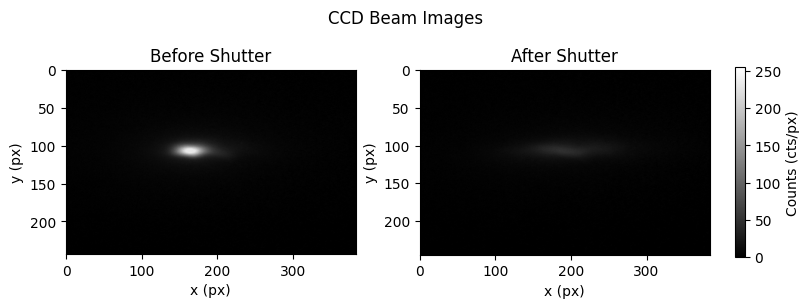

NameError: name 'run_d4sigma' is not defined

In [31]:
# --- Single-file example
filename = "drop4photo1.txt"
res = analyze_tof(10e-3, filename, make_fit_plots=False, show_split=True)

# Show per-region fit summary for this file
display(res["fit_summary"].style.format({
    "x0_px": "{:.2f}",
    "y0_px": "{:.2f}",
    "waist_x_mm (2*w0x*px)": "{:.3e}",
    "waist_y_mm (2*w0y*py)": "{:.3e}",
    "D4sigma_x_px": "{:.2f}",
    "D4sigma_y_px": "{:.2f}",
    "phi_deg": "{:.2f}",
    "bkg_avg_cts": "{:.2f}",
}))


---


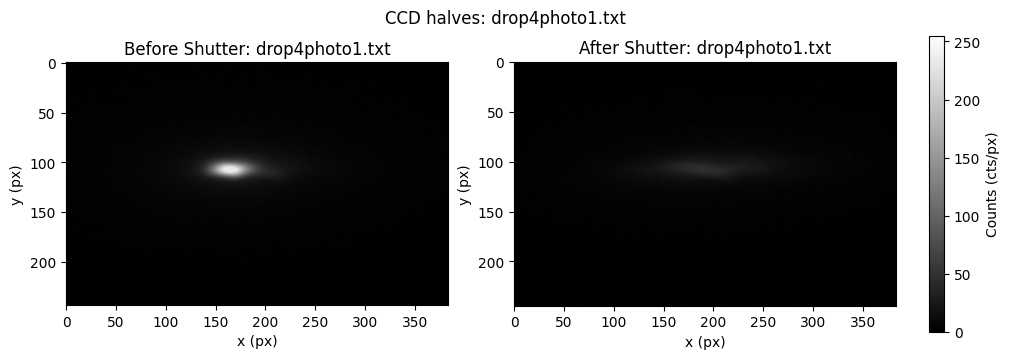

Error: Unable to determine beam parameters using moments, stopping
Error: Unable to determine beam parameters using moments, stopping


,file,tof (ms),vx (m/s),vy (m/s),Tx (uK),Ty (uK)
0,drop4photo1.txt,10.000,2.861e+00,-1.167e-01,4.178e+02,1.678e-05


In [30]:
params_dict = analyze_tof(10e-3, filename)

---


In [31]:
# --- Batch analysis across multiple files
filenames = ["drop4photo1.txt", "drop5photo1.txt", "droppic2.txt"]

batch_rows = []
for fn in filenames:
    r = analyze_tof(10e-3, fn, make_fit_plots=False, show_split=False)  # no plots in batch
    batch_rows.append({k: r[k] for k in ["file", "vx", "vy", "Tx", "Ty"]})

batch_df = pd.DataFrame(batch_rows)

display(batch_df.style.format({
    "vx": "{:.3e}",
    "vy": "{:.3e}",
    "Tx": "{:.3e}",
    "Ty": "{:.3e}",
}))


Error: Unable to determine beam parameters using moments, stopping
Error: Unable to determine beam parameters using moments, stopping


,file,tof (ms),vx (m/s),vy (m/s),Tx (uK),Ty (uK)
0,drop4photo1.txt,10.000,2.861e+00,-1.167e-01,4.178e+02,1.678e-05


Error: Unable to determine beam parameters using moments, stopping
Error: Unable to determine beam parameters using moments, stopping


,file,tof (ms),vx (m/s),vy (m/s),Tx (uK),Ty (uK)
0,drop5photo1.txt,10.000,2.397e+00,-9.171e-02,2.105e+02,7.467e-06


Error: Unable to determine beam parameters using moments, stopping
Error: Unable to determine beam parameters using moments, stopping


,file,tof (ms),vx (m/s),vy (m/s),Tx (uK),Ty (uK)
0,droppic2.txt,10.000,4.067e+00,-4.618e-01,2.025e+02,8.698e-06


,file,vx,vy,Tx,Ty
0,drop4photo1.txt,2.861e+00,-1.167e-01,4.178e-04,1.678e-11
1,drop5photo1.txt,2.397e+00,-9.171e-02,2.105e-04,7.467e-12
2,droppic2.txt,4.067e+00,-4.618e-01,2.025e-04,8.698e-12


---
